In [2]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from torch.utils.data import DataLoader, TensorDataset 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from pyts.decomposition import SingularSpectrumAnalysis

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

In [3]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
data.columns.to_list()

['observationTime',
 'absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed']

In [4]:
print(torch.version.cuda)
print(torch.cuda.is_available())

12.4
True


In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [98]:
data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

X = data.drop(columns=[
    'observationTime', 
    'missforest_precipitation', 
    # 'absorbing_aerosol_index', 
    # 'NO2_column_number_density', 
    # 'stratospheric_NO2_column_number_density', 
    # 'NO2_slant_column_number_density', 
    # 'tropopause_pressure', 
    'H2O_column_number_density', 
    # 'BrO',
    # 'NO2',
    # 'O3',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    'nh3',
    # 'pans',
    'month_sin',
    'BrO_Error',
    'NO2_Error',
    'O3_Error',
    't2m',
    'month'
    ])
y = data['missforest_precipitation']

In [7]:
X.head()

,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,NO2,O3,pm10,...,pans,tp,airTemperature,seaLevelPressure,relativeHumidity,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,-1.016247,0.000075,0.000062,0.000193,22057.926,1136.782022,4.376100e+13,3.627587e+15,332.670633,1.338105,...,1.174715,14.653358,11.295833,1010.637500,72.791667,89.375000,10.933333,3.762500,13.9,356.0
1,-0.800622,0.000079,0.000066,0.000196,22067.760,1229.531736,3.946727e+13,3.795988e+15,339.679410,1.752331,...,1.935448,6.475957,10.866667,1006.662500,94.000000,91.500000,10.429167,2.516667,7.0,327.0
2,-0.621235,0.000077,0.000062,0.000203,19219.670,1314.680602,4.465846e+13,4.526218e+15,361.533268,1.789138,...,1.787800,9.607317,13.387500,1008.454167,90.041667,89.375000,13.387500,2.537500,8.3,271.0
3,-0.659180,0.000072,0.000065,0.000146,19219.450,1824.427700,4.888972e+13,4.149200e+15,343.308865,4.323638,...,1.201320,0.013308,13.591667,1009.237500,88.291667,88.333333,13.591667,2.358333,8.7,288.0
4,-1.010234,0.000079,0.000067,0.000198,19218.373,1257.064200,4.093649e+13,3.959891e+15,311.500626,3.718909,...,1.206750,0.000000,16.291667,1008.079167,70.208333,66.000000,16.291667,1.283333,6.1,293.0


In [8]:
X_np = X.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.float32).reshape(-1, 1)

window_size = 10 
ssa = SingularSpectrumAnalysis(window_size=window_size)

In [9]:
X_ssa = ssa.fit_transform(X_np)

In [10]:
print(f"1. Original X Shape: {X_np.shape}")
print(f"2. SSA Output Shape: {X_ssa.shape}")
print(f"3. Number of lost rows: {len(X_np) - len(X_ssa)}")

1. Original X Shape: (2772, 25)
2. SSA Output Shape: (2772, 10, 25)
3. Number of lost rows: 0


In [11]:
X_flattened = X_ssa.reshape(X_ssa.shape[0], -1)
print(f"Flattened Shape: {X_flattened.shape}")

Flattened Shape: (2772, 250)


In [12]:
X_flattened[:5, :]

array([[9.57262924e+13, 1.79876843e+14, 2.74184477e+14, ...,
        2.70564818e+00, 3.84915943e+01, 3.47132591e+02],
       [9.99636713e+13, 1.87843449e+14, 2.86337400e+14, ...,
        3.72066724e+00, 8.52245606e+01, 1.87542913e+02],
       [1.19115225e+14, 2.23833080e+14, 3.41201468e+14, ...,
        3.22166644e+00, 4.90984351e+01, 2.40345553e+02],
       [1.09452827e+14, 2.05670808e+14, 3.13503710e+14, ...,
        7.61008077e-01, 3.85953341e+00, 2.87967321e+02],
       [1.04272231e+14, 1.95939895e+14, 2.98679495e+14, ...,
        4.27777553e-01, 3.04999573e+00, 2.93000000e+02]], shape=(5, 250))

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flattened)
# X_3d = X_scaled.reshape(-1, 10, 29)

print(f"Scaled 2D Shape: {X_scaled.shape}")
# print(f"Final 3D Shape for LSTM: {X_3d.shape}")

Scaled 2D Shape: (2772, 250)


In [65]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout = 0):
        super().__init__()
        self.input_dim = input_dim
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        # self.fc = nn.Linear(hidden_dim, 1)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.input_dim)
        
        out, _ = self.lstm(x)
        last_step = out[:, -1, :] 
        return self.fc(last_step)

In [16]:
model = LSTMRegressor(input_dim=29, hidden_dim=128, num_layers=3)
print(model)

LSTMRegressor(
  (lstm): LSTM(29, 128, num_layers=3, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [17]:
net = NeuralNetRegressor(
    module=LSTMRegressor,
    module__input_dim=29,
    module__hidden_dim=128,
    module__num_layers=3,
    module__dropout=0.2,
    max_epochs=50,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    criterion=nn.MSELoss,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [18]:
def reshape_to_2d(x):
    return x.reshape(x.shape[0], -1)

def reshape_to_3d(x):
    return x.reshape(-1, 10, 29)

def cast_to_float32(x):
    return x.astype(np.float32)

In [99]:
split_idx = int(len(X_np) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

y_train_series = y_train.values.astype('float32').reshape(-1, 1)
y_test_series = y_test.values.astype('float32').reshape(-1, 1)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 2217
Testing samples:  555


window 10, layers 2, drop 0,2, cells 64, cor = 0.68

In [106]:
from skorch.callbacks import Checkpoint, EarlyStopping
from sklearn.compose import ColumnTransformer

N_FEATURES = X_train.shape[1] # Automatically detects number of columns (29)
WINDOW_SIZE = 10

# pipeline = Pipeline([
#     ('ssa', SingularSpectrumAnalysis(window_size=WINDOW_SIZE)),
    
#     ('flatten', FunctionTransformer(reshape_to_2d)),
    
#     ('scaler', StandardScaler()),

#     ('cast_float32', FunctionTransformer(cast_to_float32)),
    
#     ('lstm_model', NeuralNetRegressor(
#         module=LSTMRegressor,
#         module__input_dim=N_FEATURES,
#         module__hidden_dim=20,
#         module__num_layers=3,
#         module__dropout=0.15,
#         max_epochs=50,
#         lr=0.001,
#         callbacks=[
#             # ('early_stopping', EarlyStopping(patience=5)), # Stops if no improvement in 5 epochs
#             ('checkpoint', Checkpoint(monitor='valid_loss_best')), # Keeps the best version
#         ],
#         batch_size=32,
#         optimizer=torch.optim.Adam,
#         criterion=nn.MSELoss,
#         device='cuda' if torch.cuda.is_available() else 'cpu'
#     ))
# ])

ssa_features = [col for col in X.columns if col != 'tp']
passthrough_features = ['tp', 'month_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('ssa_path', Pipeline([
            ('ssa', SingularSpectrumAnalysis(window_size=WINDOW_SIZE)),
            ('flatten_ssa', FunctionTransformer(reshape_to_2d)),
            ('scaler_ssa', StandardScaler())
        ]), ssa_features),
        
        ('bypass_path', StandardScaler(), passthrough_features)
    ]
)

pipeline = Pipeline([
    ('prep', preprocessor),
    
    ('cast_float32', FunctionTransformer(cast_to_float32)),
    
    ('lstm_model', NeuralNetRegressor(
        module=LSTMRegressor,
        module__input_dim=(len(ssa_features) * WINDOW_SIZE) + 2, 
        module__hidden_dim=64,
        module__num_layers=2,
        module__dropout=0.2,
        max_epochs=25,
        lr=0.001,
        callbacks=[('checkpoint', Checkpoint(monitor='valid_loss_best'))],
        batch_size=32,
        optimizer=torch.optim.Adam,
        criterion = nn.HuberLoss,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    ))
])

In [107]:
pipeline.fit(X_train, y_train_series)

y_pred = pipeline.predict(X_test)

history = pipeline.named_steps['lstm_model'].history
valid_losses = [epoch['valid_loss'] for epoch in history]

best_loss = min(valid_losses)
best_epoch = valid_losses.index(best_loss) + 1

print(f"Best Validation Loss: {best_loss:.4f} at Epoch: {best_epoch}")

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        1.5490        1.2055     +  0.3170
      2        1.3373        1.1202     +  0.2437
      3        1.2820        1.0895     +  0.2201
      4        1.2660        1.0735     +  0.1938
      5        1.2293        1.0708     +  0.1966
      6        1.2195        1.0738        0.1960
      7        1.1905        1.0613     +  0.1970
      8        1.1796        1.0610     +  0.1973
      9        1.1417        1.0687        0.2067
     10        1.1371        1.0410     +  0.1970
     11        1.1196        1.0577        0.2068
     12        1.1329        1.0530        0.1997
     13        1.1010        1.0746        0.1939
     14        1.0458        1.0496        0.1901
     15        1.0578        1.0547        0.2005
     16        1.0690        1.0912        0.2411
     17        1.0530        1.1257        0.2447
     18        1.0057        1.1139        0.1997


In [108]:
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

rmse = np.sqrt(mean_squared_error(y_test_series, y_pred))
print(f"\nFinal Test RMSE: {rmse:.4f}")

corr, _ = spearmanr(y_test_series.flatten(), y_pred.flatten())
print(f"Spearman Rank Correlation: {corr:.4f}")

# Compare a few values
comparison = pd.DataFrame({'Actual': y_test.to_numpy().flatten(), 'Predicted': y_pred.flatten()})
print("\nFirst 5 Predictions vs Actual:")
print(comparison.head())


Final Test RMSE: 3.9355
Spearman Rank Correlation: 0.6823

First 5 Predictions vs Actual:
   Actual  Predicted
0     0.9   4.061441
1     0.0   0.373591
2    13.4   5.651057
3    68.9  22.216139
4     0.1   3.325851


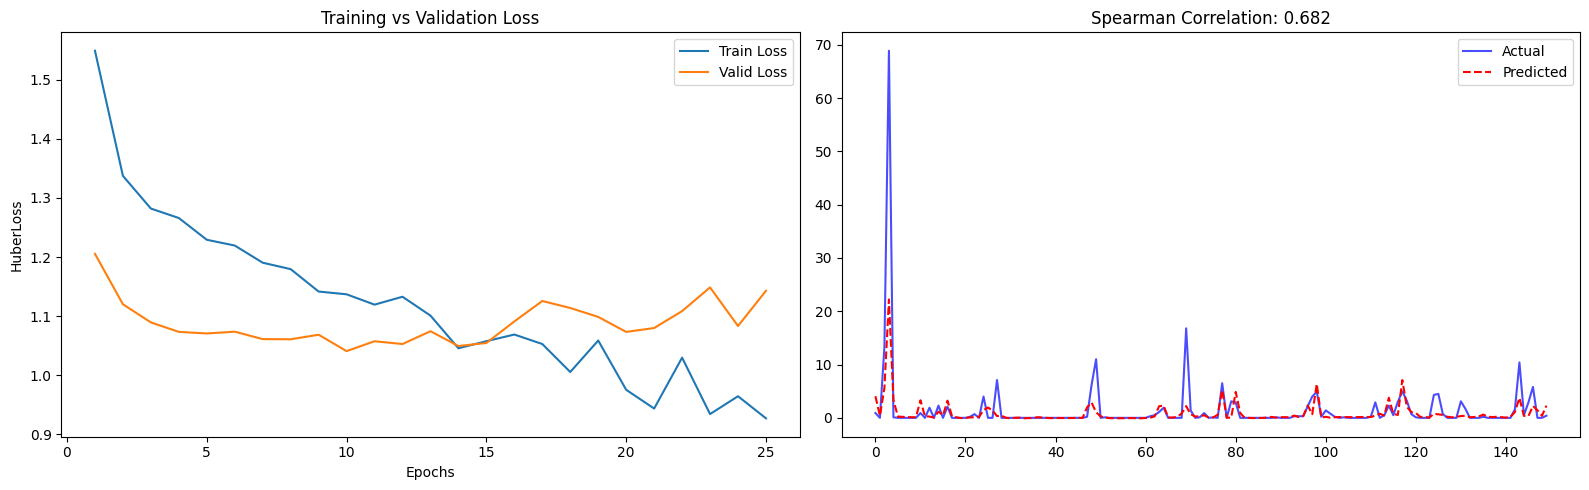

In [111]:
history = pipeline.named_steps['lstm_model'].history

train_loss = history[:, 'train_loss']
valid_loss = history[:, 'valid_loss']
epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(epochs, train_loss, label='Train Loss')
ax1.plot(epochs, valid_loss, label='Valid Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('HuberLoss')
ax1.legend()

ax2.plot(y_test.reset_index(drop='index')[:150], label='Actual', color='blue', alpha=0.7)
ax2.plot(y_pred[:150], label='Predicted', color='red', linestyle='--')
ax2.set_title(f'Spearman Correlation: {corr:.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

Number of importance scores: 24
Number of feature names: 24


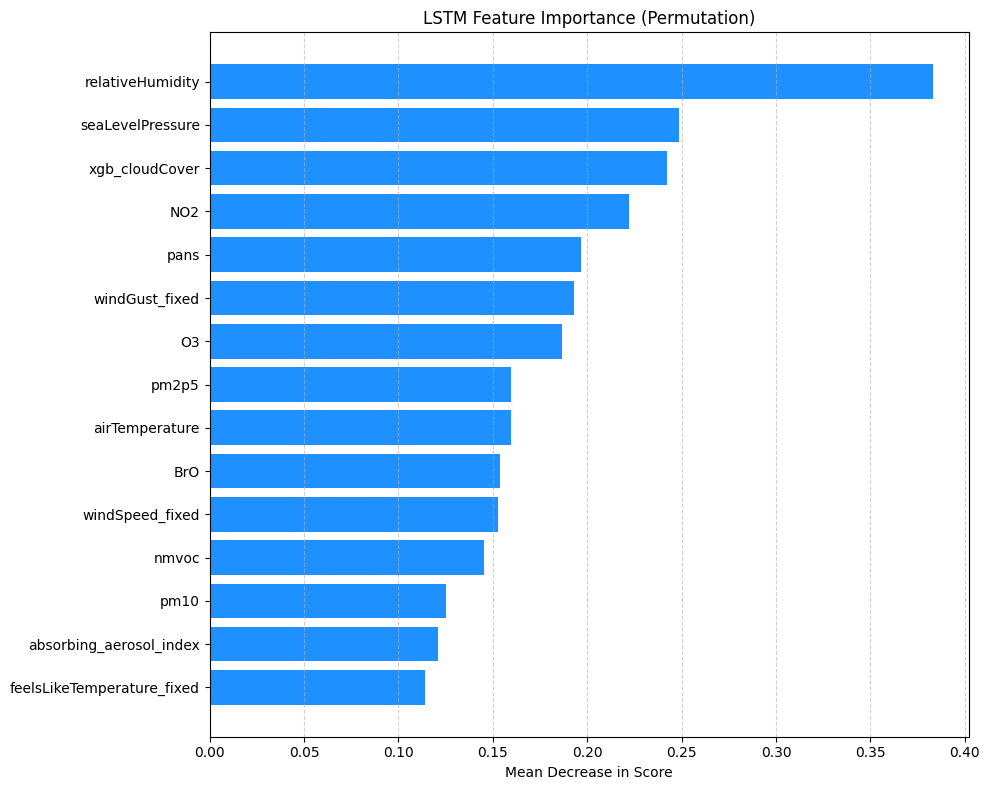

                                    feature  importance
17                         relativeHumidity    0.383006
16                         seaLevelPressure    0.248649
18                           xgb_cloudCover    0.242461
6                                       NO2    0.222180
13                                     pans    0.196908
21                           windGust_fixed    0.193026
7                                        O3    0.186705
9                                     pm2p5    0.159748
15                           airTemperature    0.159642
5                                       BrO    0.153989
20                          windSpeed_fixed    0.152979
11                                    nmvoc    0.145181
8                                      pm10    0.125114
0                   absorbing_aerosol_index    0.120928
19               feelsLikeTemperature_fixed    0.114069
12                                     dust    0.113976
4                       tropopause_pressure    0

In [ ]:
from sklearn.inspection import permutation_importance

feature_names = data.drop(columns=[
    'observationTime', 
    'missforest_precipitation', 
    'BrO_Error',
    'NO2_Error',
    'O3_Error',
    't2m',
    'month',
    'nh3',
    'month_sin',
    'H2O_column_number_density'
]).columns.tolist()


result = permutation_importance(
    pipeline, X_test, y_test, 
    n_repeats=5,
    random_state=42
)

print(f"Number of importance scores: {len(result.importances_mean)}")
print(f"Number of feature names: {len(X.columns)}")

if len(feature_names) == len(result.importances_mean):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': result.importances_mean
    }).sort_values(by='importance', ascending=False)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['feature'][:15][::-1], importance_df['importance'][:15][::-1], color='dodgerblue')
    plt.title("LSTM Feature Importance (Permutation)")
    plt.xlabel("Mean Decrease in Score")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(importance_df)
else:
    print(f"Mismatch! Scores: {len(result.importances_mean)}, Names: {len(feature_names)}")